# Test Notebook: Improved Boost Factor Likelihood (DES Y1)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Add module directory to path
sys.path.insert(0, '/Users/aa3044/Documents/GitHub/Boost_factor_cosmosis/improved_module')

from bf_likelihood_improved import (
    boost_factor_model,
    load_y1_data,
    discover_y1_bins,
    compute_likelihood_standalone,
    generate_values_ini
)

print("Module imported successfully!")

Module imported successfully!


## 1. Test the Boost Factor Model

The model is: $B(R) = 1 + b_0 \frac{1 - f(x)}{x^2 - 1}$ where $x = R/r_s$

At $x = 1$: $B = (b_0 + 3) / 3$ (analytic limit)

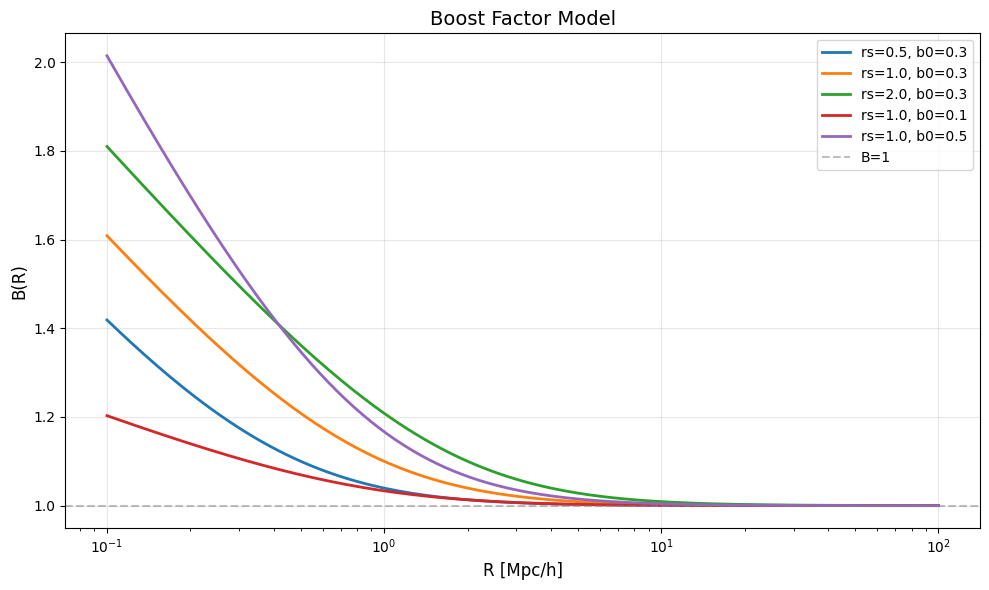

In [2]:
# Test the model
R_test = np.logspace(-1, 2, 200)

fig, ax = plt.subplots(figsize=(10, 6))

# Different parameter combinations
params = [
    (0.5, 0.3, 'rs=0.5, b0=0.3'),
    (1.0, 0.3, 'rs=1.0, b0=0.3'),
    (2.0, 0.3, 'rs=2.0, b0=0.3'),
    (1.0, 0.1, 'rs=1.0, b0=0.1'),
    (1.0, 0.5, 'rs=1.0, b0=0.5'),
]

for rs, b0, label in params:
    B = boost_factor_model(R_test, rs, b0)
    ax.plot(R_test, B, label=label, lw=2)

ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='B=1')
ax.set_xscale('log')
ax.set_xlabel('R [Mpc/h]', fontsize=12)
ax.set_ylabel('B(R)', fontsize=12)
ax.set_title('Boost Factor Model', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# Verify the limit at x=1
rs_test, b0_test = 1.0, 0.3
expected = (b0_test + 3) / 3
computed = boost_factor_model(np.array([rs_test]), rs_test, b0_test)[0]

print("Limit test at x=1 (R=rs):")
print(f"  Expected: (b0+3)/3 = {expected:.6f}")
print(f"  Computed: {computed:.6f}")
print(f"  Match: {np.isclose(expected, computed)}")

Limit test at x=1 (R=rs):
  Expected: (b0+3)/3 = 1.100000
  Computed: 1.100000
  Match: True


## 2. Test Likelihood Computation with Mock Data

Since Y1 data is on NERSC, we'll test with mock data here.

In [4]:
# Create mock Y1-like data
np.random.seed(42)

# True parameters
true_rs = 0.8
true_b0 = 0.25

# Mock radial bins (like Y1 data)
R_mock = np.array([0.1, 0.2, 0.4, 0.8, 1.6, 3.2, 6.4, 12.8])

# Generate mock boost factor data with noise
B_true = boost_factor_model(R_mock, true_rs, true_b0)
noise_level = 0.02
B_mock = B_true + np.random.normal(0, noise_level, len(R_mock))

# Mock covariance (diagonal)
cov_mock = np.diag(np.ones(len(R_mock)) * noise_level**2)

print("Mock Y1-like data:")
print(f"  True parameters: rs={true_rs}, b0={true_b0}")
print(f"  R bins: {R_mock}")
print(f"  B(R): {np.round(B_mock, 4)}")

Mock Y1-like data:
  True parameters: rs=0.8, b0=0.25
  R bins: [ 0.1  0.2  0.4  0.8  1.6  3.2  6.4 12.8]
  B(R): [1.4647 1.2989 1.1865 1.1138 1.0283 1.0063 1.0348 1.0162]


In [5]:
# Grid search for best-fit on mock data
rs_grid = np.logspace(-1, 1, 50)
b0_grid = np.logspace(-1.5, 0.5, 50)

log_L_grid = np.zeros((len(rs_grid), len(b0_grid)))

for i, rs in enumerate(rs_grid):
    for j, b0 in enumerate(b0_grid):
        log_L, _, _ = compute_likelihood_standalone(R_mock, B_mock, cov_mock, rs, b0)
        log_L_grid[i, j] = log_L

# Find best-fit
best_idx = np.unravel_index(np.argmax(log_L_grid), log_L_grid.shape)
best_rs = rs_grid[best_idx[0]]
best_b0 = b0_grid[best_idx[1]]

print(f"Grid search results:")
print(f"  True:     rs={true_rs:.3f}, b0={true_b0:.3f}")
print(f"  Best-fit: rs={best_rs:.3f}, b0={best_b0:.3f}")

Grid search results:
  True:     rs=0.800, b0=0.250
  Best-fit: rs=0.954, b0=0.228


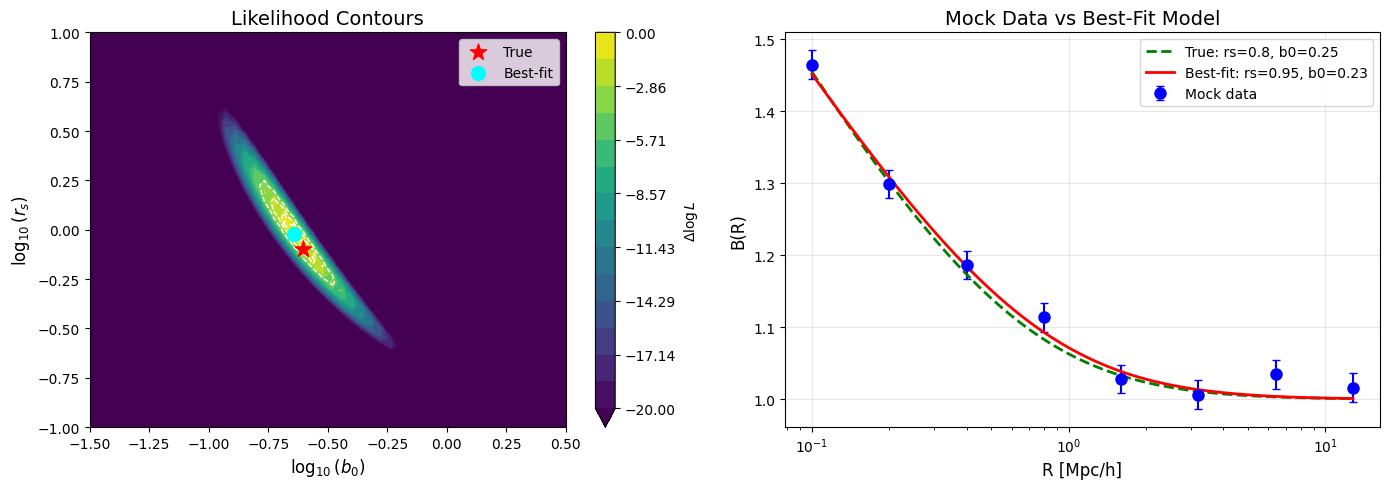

In [6]:
# Plot likelihood contours
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Likelihood contours
ax = axes[0]
log_L_norm = log_L_grid - np.max(log_L_grid)
levels = np.linspace(-20, 0, 15)
cs = ax.contourf(np.log10(b0_grid), np.log10(rs_grid), log_L_norm, 
                 levels=levels, cmap='viridis', extend='min')
ax.contour(np.log10(b0_grid), np.log10(rs_grid), log_L_norm, 
           levels=[-4.61, -2.30, -1.15], colors='white', linewidths=1)
ax.scatter(np.log10(true_b0), np.log10(true_rs), color='red', s=150, 
           marker='*', label=f'True', zorder=5)
ax.scatter(np.log10(best_b0), np.log10(best_rs), color='cyan', s=100, 
           marker='o', label=f'Best-fit', zorder=5)
plt.colorbar(cs, ax=ax, label=r'$\Delta \log L$')
ax.set_xlabel(r'$\log_{10}(b_0)$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(r_s)$', fontsize=12)
ax.set_title('Likelihood Contours', fontsize=14)
ax.legend()

# Right: Data vs Model
ax = axes[1]
ax.errorbar(R_mock, B_mock, yerr=noise_level, fmt='o', capsize=3, 
            label='Mock data', color='blue', markersize=8)
R_fine = np.logspace(np.log10(R_mock.min()), np.log10(R_mock.max()), 100)
ax.plot(R_fine, boost_factor_model(R_fine, true_rs, true_b0), 'g--', 
        lw=2, label=f'True: rs={true_rs}, b0={true_b0}')
ax.plot(R_fine, boost_factor_model(R_fine, best_rs, best_b0), 'r-', 
        lw=2, label=f'Best-fit: rs={best_rs:.2f}, b0={best_b0:.2f}')
ax.set_xscale('log')
ax.set_xlabel('R [Mpc/h]', fontsize=12)
ax.set_ylabel('B(R)', fontsize=12)
ax.set_title('Mock Data vs Best-Fit Model', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Generate CosmoSIS Configuration Files

In [7]:
# Y1 bins: 4 richness (l=0-3) x 3 redshift (z=0-2) = 12 bins
y1_bins = [(l, z) for l in range(4) for z in range(3)]

print("DES Y1 bins:")
for i, (l, z) in enumerate(y1_bins):
    print(f"  {i+1:2d}. l={l}, z={z}")

DES Y1 bins:
   1. l=0, z=0
   2. l=0, z=1
   3. l=0, z=2
   4. l=1, z=0
   5. l=1, z=1
   6. l=1, z=2
   7. l=2, z=0
   8. l=2, z=1
   9. l=2, z=2
  10. l=3, z=0
  11. l=3, z=1
  12. l=3, z=2


In [8]:
# Generate values.ini file
output_file = '/Users/aa3044/Documents/GitHub/Boost_factor_cosmosis/improved_module/bf_values_all_bins.ini'

generate_values_ini(
    bins=y1_bins,
    output_file=output_file,
    prior_range=(-1.0, 0.0, 1.0)
)

# Display the file
with open(output_file, 'r') as f:
    print(f.read())

Generated values file: /Users/aa3044/Documents/GitHub/Boost_factor_cosmosis/improved_module/bf_values_all_bins.ini
[boost_factor_params]
# Parameter file for boost factor model - DES Y1
# 4 richness bins (l=0-3) x 3 redshift bins (z=0-2) = 12 bins
# Format: logrs_lX_zY = min start max

logrs_l0_z0 = -1.0 0.0 1.0
logb0_l0_z0 = -1.0 0.0 1.0
logrs_l0_z1 = -1.0 0.0 1.0
logb0_l0_z1 = -1.0 0.0 1.0
logrs_l0_z2 = -1.0 0.0 1.0
logb0_l0_z2 = -1.0 0.0 1.0
logrs_l1_z0 = -1.0 0.0 1.0
logb0_l1_z0 = -1.0 0.0 1.0
logrs_l1_z1 = -1.0 0.0 1.0
logb0_l1_z1 = -1.0 0.0 1.0
logrs_l1_z2 = -1.0 0.0 1.0
logb0_l1_z2 = -1.0 0.0 1.0
logrs_l2_z0 = -1.0 0.0 1.0
logb0_l2_z0 = -1.0 0.0 1.0
logrs_l2_z1 = -1.0 0.0 1.0
logb0_l2_z1 = -1.0 0.0 1.0
logrs_l2_z2 = -1.0 0.0 1.0
logb0_l2_z2 = -1.0 0.0 1.0
logrs_l3_z0 = -1.0 0.0 1.0
logb0_l3_z0 = -1.0 0.0 1.0
logrs_l3_z1 = -1.0 0.0 1.0
logb0_l3_z1 = -1.0 0.0 1.0
logrs_l3_z2 = -1.0 0.0 1.0
logb0_l3_z2 = -1.0 0.0 1.0
